# ## Section 1: Import Libraries

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# PyTorch Geometric (GNN library)
try:
    import torch_geometric
    from torch_geometric.data import Data, DataLoader as GeoDataLoader
    from torch_geometric.nn import GCNConv, global_mean_pool, global_max_pool
    print(f"PyTorch Geometric version: {torch_geometric.__version__}")
except ImportError:
    print("ERROR: PyTorch Geometric not installed!")
    print("Install with: pip install torch-geometric")

# Image Processing
import numpy as np
import pandas as pd
from PIL import Image
import cv2
from skimage.segmentation import slic
from skimage.color import rgb2gray
from skimage.feature import graycomatrix, graycoprops
from scipy.spatial import distance_matrix

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle

# Metrics
from sklearn.metrics import (
    confusion_matrix, 
    classification_report, 
    roc_curve, 
    auc,
    f1_score, 
    recall_score, 
    precision_score
)
from sklearn.preprocessing import label_binarize

# Utilities
import os
import json
import time
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

PyTorch Geometric version: 2.7.0
All libraries imported successfully!


# ## Section 2: Environment Verification

In [3]:
print("="*80)
print("ENVIRONMENT VERIFICATION")
print("="*80)

print(f"\nPyTorch Version: {torch.__version__}")

if torch.cuda.is_available():
    print(f"CUDA Available: {torch.cuda.is_available()}")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    
    for i in range(torch.cuda.device_count()):
        gpu_name = torch.cuda.get_device_name(i)
        gpu_memory = torch.cuda.get_device_properties(i).total_memory / 1e9
        print(f"\n   GPU {i}: {gpu_name}")
        print(f"   Memory: {gpu_memory:.2f} GB")
    
    device = torch.device('cuda:0')
    print(f"\nUsing device: {device}")
else:
    print("CUDA not available. Using CPU.")
    device = torch.device('cpu')

print("\n" + "="*80)
print("Environment ready!")
print("="*80)

ENVIRONMENT VERIFICATION

PyTorch Version: 2.1.2+cu118
CUDA Available: True
Number of GPUs: 2

   GPU 0: NVIDIA RTX A6000
   Memory: 51.53 GB

   GPU 1: NVIDIA RTX A6000
   Memory: 51.53 GB

Using device: cuda:0

Environment ready!


# ## Section 3: Configuration

In [5]:
CONFIG = {
    # Paths
    'DATA_DIR': r'C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\data\Alzheimer_MRI_4_classes_dataset',
    'OUTPUT_DIR': r'C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\outputs\Q3\Q3a',
    
    # Graph construction
    'IMG_SIZE': 128,  # Resize for faster processing
    'NUM_SUPERPIXELS': 75,  # Number of superpixels (nodes in graph)
    'COMPACTNESS': 10,  # SLIC compactness parameter
    'K_NEIGHBORS': 8,  # Number of nearest neighbors for graph edges
    
    # Node features
    'NODE_FEATURE_DIM': 128,  # Dimension of node features
    
    # GNN architecture
    'GCN_HIDDEN_DIM': 256,
    'GCN_NUM_LAYERS': 3,
    'DROPOUT': 0.5,
    
    # Training
    'BATCH_SIZE': 32,  # Smaller batch size for graphs
    'LEARNING_RATE': 0.001,
    'MAX_EPOCHS': 100,
    
    # Classes
    'NUM_CLASSES': 4,
    'CLASS_NAMES': ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented'],
    
    # Data split
    'TRAIN_SPLIT': 0.8,
    'VAL_SPLIT': 0.1,
    'TEST_SPLIT': 0.1,
    
    # Early stopping
    'EARLY_STOP_PATIENCE': 10,
    'EARLY_STOP_MIN_DELTA': 0.001,
    
    # Learning rate scheduler
    'LR_PATIENCE': 5,
    'LR_FACTOR': 0.5,
    
    'RANDOM_SEED': 42,
    'NUM_WORKERS': 0
}

torch.manual_seed(CONFIG['RANDOM_SEED'])
np.random.seed(CONFIG['RANDOM_SEED'])
if torch.cuda.is_available():
    torch.cuda.manual_seed(CONFIG['RANDOM_SEED'])

os.makedirs(CONFIG['OUTPUT_DIR'], exist_ok=True)

if not os.path.exists(CONFIG['DATA_DIR']):
    print(f"\nERROR: Data directory not found at {CONFIG['DATA_DIR']}")
else:
    print("\nConfiguration loaded successfully!")
    print(f"\nPaths:")
    print(f"   Data: {CONFIG['DATA_DIR']}")
    print(f"   Output: {CONFIG['OUTPUT_DIR']}")
    
    print(f"\nGraph Construction:")
    print(f"   Image size: {CONFIG['IMG_SIZE']}x{CONFIG['IMG_SIZE']}")
    print(f"   Superpixels (nodes): {CONFIG['NUM_SUPERPIXELS']}")
    print(f"   K-nearest neighbors: {CONFIG['K_NEIGHBORS']}")
    
    print(f"\nGNN Architecture:")
    print(f"   Node feature dim: {CONFIG['NODE_FEATURE_DIM']}")
    print(f"   GCN hidden dim: {CONFIG['GCN_HIDDEN_DIM']}")
    print(f"   GCN layers: {CONFIG['GCN_NUM_LAYERS']}")
    print(f"   Dropout: {CONFIG['DROPOUT']}")
    
    print(f"\nTraining Settings:")
    print(f"   Batch size: {CONFIG['BATCH_SIZE']}")
    print(f"   Learning rate: {CONFIG['LEARNING_RATE']}")
    print(f"   Max epochs: {CONFIG['MAX_EPOCHS']} (with early stopping)")


Configuration loaded successfully!

Paths:
   Data: C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\data\Alzheimer_MRI_4_classes_dataset
   Output: C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\outputs\Q3\Q3a

Graph Construction:
   Image size: 128x128
   Superpixels (nodes): 75
   K-nearest neighbors: 8

GNN Architecture:
   Node feature dim: 128
   GCN hidden dim: 256
   GCN layers: 3
   Dropout: 0.5

Training Settings:
   Batch size: 32
   Learning rate: 0.001
   Max epochs: 100 (with early stopping)


# ## Section 4: Helper Functions

In [6]:
class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.best_epoch = 0
        
    def __call__(self, val_loss, epoch):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.best_epoch = epoch
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.best_epoch = epoch
            self.counter = 0
        
        return self.early_stop


class MetricTracker:
    def __init__(self):
        self.history = {
            'epoch': [],
            'train_loss': [],
            'train_acc': [],
            'val_loss': [],
            'val_acc': [],
            'val_f1': [],
            'val_precision': [],
            'val_recall': [],
            'learning_rate': [],
            'epoch_time': []
        }
    
    def update(self, epoch, metrics):
        self.history['epoch'].append(epoch)
        for key, value in metrics.items():
            if key in self.history:
                self.history[key].append(value)
    
    def get_best(self, metric='val_acc', mode='max'):
        if mode == 'max':
            return max(self.history[metric])
        else:
            return min(self.history[metric])
    
    def save_csv(self, filepath):
        df = pd.DataFrame(self.history)
        df.to_csv(filepath, index=False)


def format_time(seconds):
    hours = int(seconds // 3600)
    minutes = int((seconds % 3600) // 60)
    secs = int(seconds % 60)
    
    if hours > 0:
        return f"{hours}h {minutes}m {secs}s"
    elif minutes > 0:
        return f"{minutes}m {secs}s"
    else:
        return f"{secs}s"


def print_training_summary(epoch, total_epochs, metrics, epoch_time):
    print(f"\n{'='*80}")
    print(f"Epoch {epoch}/{total_epochs} - {format_time(epoch_time)}")
    print(f"{'='*80}")
    print(f"Train Loss: {metrics['train_loss']:.4f} | Train Acc: {metrics['train_acc']:.2f}%")
    print(f"Val Loss:   {metrics['val_loss']:.4f} | Val Acc:   {metrics['val_acc']:.2f}%")
    print(f"Val F1:     {metrics['val_f1']:.4f} | Precision:  {metrics['val_precision']:.4f} | Recall: {metrics['val_recall']:.4f}")
    print(f"Learning Rate: {metrics['learning_rate']:.6f}")


print("Helper functions defined successfully!")

Helper functions defined successfully!


# ## Section 5: Graph Construction Functions

In [7]:
def extract_node_features(image, segments):
    """
    Extract features for each superpixel (node)
    
    Features:
    - Mean RGB color (3 values)
    - Color std dev (3 values)
    - Texture features (GLCM - 4 values)
    - Centroid position (2 values)
    - Area (1 value)
    
    Total: 13 base features, then expanded with CNN-like processing
    """
    num_segments = segments.max() + 1
    features = []
    centroids = []
    
    gray_image = rgb2gray(image)
    
    for seg_id in range(num_segments):
        mask = segments == seg_id
        
        # Color features
        region_pixels = image[mask]
        mean_color = region_pixels.mean(axis=0)
        std_color = region_pixels.std(axis=0)
        
        # Texture features (GLCM)
        region_gray = (gray_image[mask] * 255).astype(np.uint8)
        if len(region_gray) > 10:
            # Create small patch for GLCM
            coords = np.argwhere(mask)
            min_coords = coords.min(axis=0)
            max_coords = coords.max(axis=0)
            
            patch = gray_image[min_coords[0]:max_coords[0]+1, 
                             min_coords[1]:max_coords[1]+1]
            patch = (patch * 255).astype(np.uint8)
            
            if patch.size > 0:
                glcm = graycomatrix(patch, [1], [0], levels=256, symmetric=True, normed=True)
                contrast = graycoprops(glcm, 'contrast')[0, 0]
                dissimilarity = graycoprops(glcm, 'dissimilarity')[0, 0]
                homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
                energy = graycoprops(glcm, 'energy')[0, 0]
            else:
                contrast = dissimilarity = homogeneity = energy = 0
        else:
            contrast = dissimilarity = homogeneity = energy = 0
        
        # Position features
        coords = np.argwhere(mask)
        centroid = coords.mean(axis=0)
        area = mask.sum()
        
        # Normalize position to [0, 1]
        norm_centroid = centroid / np.array(image.shape[:2])
        norm_area = area / (image.shape[0] * image.shape[1])
        
        # Combine all features
        node_feature = np.concatenate([
            mean_color,  # 3
            std_color,   # 3
            [contrast, dissimilarity, homogeneity, energy],  # 4
            norm_centroid,  # 2
            [norm_area]  # 1
        ])
        
        features.append(node_feature)
        centroids.append(centroid)
    
    return np.array(features), np.array(centroids)


def construct_graph(image_path, num_superpixels, compactness, k_neighbors):
    """
    Convert image to graph structure
    
    Steps:
    1. Load and resize image
    2. Apply SLIC superpixel segmentation
    3. Extract features for each superpixel
    4. Construct k-NN graph based on spatial proximity
    5. Return PyTorch Geometric Data object
    """
    # Load image
    image = Image.open(image_path).convert('RGB')
    image = image.resize((CONFIG['IMG_SIZE'], CONFIG['IMG_SIZE']))
    image = np.array(image) / 255.0  # Normalize to [0, 1]
    
    # Superpixel segmentation
    segments = slic(image, n_segments=num_superpixels, 
                   compactness=compactness, start_label=0)
    
    # Extract node features
    node_features, centroids = extract_node_features(image, segments)
    
    # Construct edges using k-NN on centroids
    dist_matrix = distance_matrix(centroids, centroids)
    
    edge_index = []
    for i in range(len(centroids)):
        # Find k nearest neighbors (excluding self)
        distances = dist_matrix[i]
        nearest = np.argsort(distances)[1:k_neighbors+1]  # Skip self (index 0)
        
        for j in nearest:
            edge_index.append([i, j])
    
    edge_index = np.array(edge_index).T
    
    # Convert to PyTorch tensors
    x = torch.FloatTensor(node_features)
    edge_index = torch.LongTensor(edge_index)
    
    return x, edge_index, segments


print("Graph construction functions defined!")
print("\nKey capabilities:")
print("  • extract_node_features - Extracts 13-dimensional features per superpixel")
print("  • construct_graph - Converts image to graph (nodes + edges)")
print("  • Uses SLIC for superpixel segmentation")
print("  • K-NN for graph connectivity")

Graph construction functions defined!

Key capabilities:
  • extract_node_features - Extracts 13-dimensional features per superpixel
  • construct_graph - Converts image to graph (nodes + edges)
  • Uses SLIC for superpixel segmentation
  • K-NN for graph connectivity


# ## Section 6: Load and Prepare Data

In [8]:
print("Loading image paths and labels...\n")

all_images = []
all_labels = []

for class_idx, class_name in enumerate(CONFIG['CLASS_NAMES']):
    class_dir = os.path.join(CONFIG['DATA_DIR'], class_name)
    if os.path.exists(class_dir):
        image_files = [f for f in os.listdir(class_dir) 
                      if f.endswith(('.jpg', '.jpeg', '.png'))]
        
        for img_file in image_files:
            all_images.append(os.path.join(class_dir, img_file))
            all_labels.append(class_idx)
        
        print(f"  {class_name} (class {class_idx}): {len(image_files)} images")

all_images = np.array(all_images)
all_labels = np.array(all_labels, dtype=np.int64)

print(f"\nLoaded {len(all_images):,} total images")

# Shuffle
np.random.seed(CONFIG['RANDOM_SEED'])
indices = np.random.permutation(len(all_images))
all_images = all_images[indices]
all_labels = all_labels[indices]

# Split
n_samples = len(all_images)
train_end = int(CONFIG['TRAIN_SPLIT'] * n_samples)
val_end = train_end + int(CONFIG['VAL_SPLIT'] * n_samples)

train_images = all_images[:train_end]
train_labels = all_labels[:train_end]

val_images = all_images[train_end:val_end]
val_labels = all_labels[train_end:val_end]

test_images = all_images[val_end:]
test_labels = all_labels[val_end:]

print(f"\nDataset Split:")
print(f"  Training:   {len(train_images):,} images")
print(f"  Validation: {len(val_images):,} images")
print(f"  Test:       {len(test_images):,} images")

Loading image paths and labels...

  MildDemented (class 0): 896 images
  ModerateDemented (class 1): 64 images
  NonDemented (class 2): 3200 images
  VeryMildDemented (class 3): 2240 images

Loaded 6,400 total images

Dataset Split:
  Training:   5,120 images
  Validation: 640 images
  Test:       640 images


# ## Section 7: Visualize Sample Graphs

Visualizing sample graph construction...

Graph visualization saved to: C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\outputs\Q3\Q3a\graph_construction_example.png


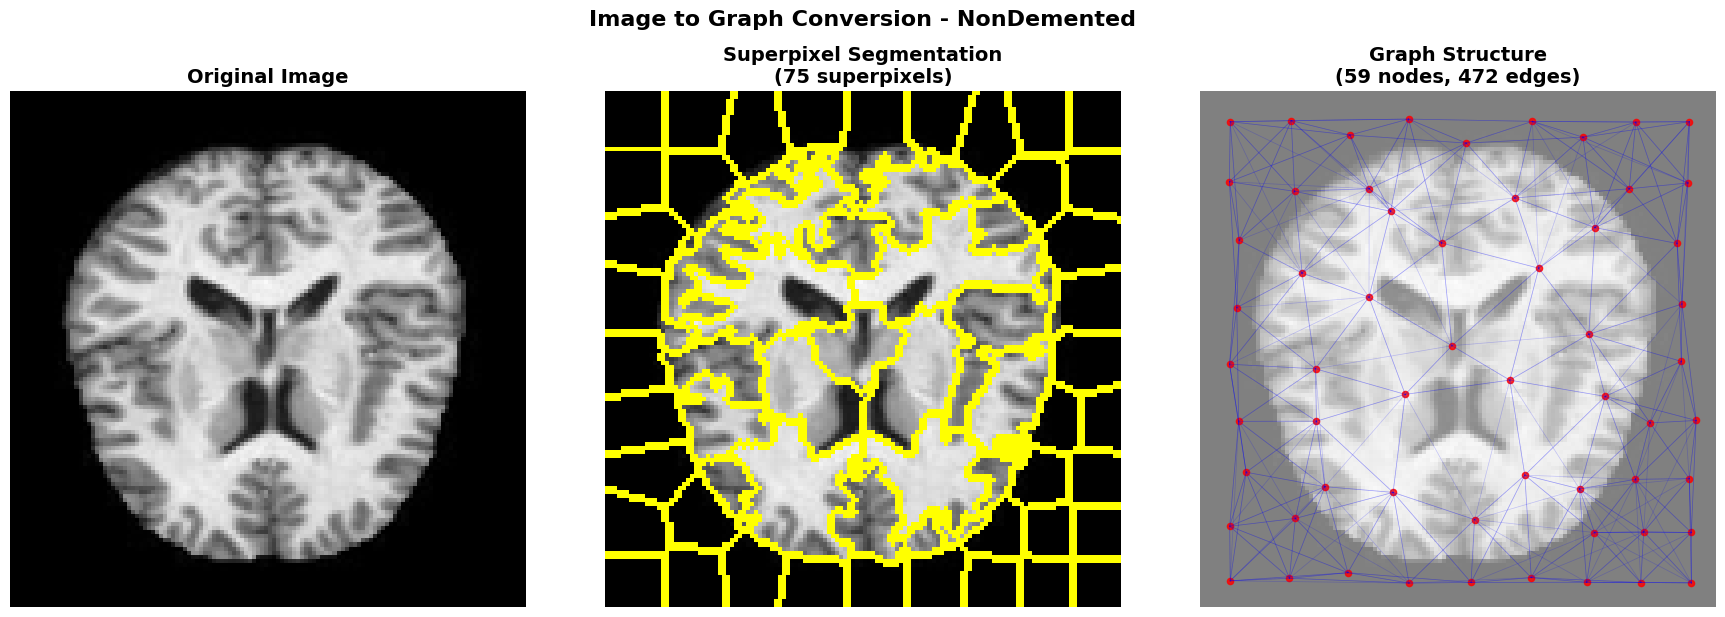


Graph statistics:
  Number of nodes: 59
  Node feature dimension: 13
  Number of edges: 472
  Average degree: 8.00


In [9]:
print("Visualizing sample graph construction...\n")

# Take one sample image
sample_idx = 0
sample_image_path = train_images[sample_idx]
sample_label = train_labels[sample_idx]

# Load original image
original_image = Image.open(sample_image_path).convert('RGB')
original_image_resized = original_image.resize((CONFIG['IMG_SIZE'], CONFIG['IMG_SIZE']))
original_array = np.array(original_image_resized)

# Construct graph
x, edge_index, segments = construct_graph(
    sample_image_path,
    CONFIG['NUM_SUPERPIXELS'],
    CONFIG['COMPACTNESS'],
    CONFIG['K_NEIGHBORS']
)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Original image
axes[0].imshow(original_array)
axes[0].set_title('Original Image', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Superpixel segmentation
from skimage.segmentation import mark_boundaries
boundaries = mark_boundaries(original_array / 255.0, segments)
axes[1].imshow(boundaries)
axes[1].set_title(f'Superpixel Segmentation\n({CONFIG["NUM_SUPERPIXELS"]} superpixels)', 
                 fontsize=14, fontweight='bold')
axes[1].axis('off')

# Graph visualization
axes[2].imshow(original_array, alpha=0.5)

# Extract centroids for visualization
centroids = []
for seg_id in range(segments.max() + 1):
    mask = segments == seg_id
    coords = np.argwhere(mask)
    centroid = coords.mean(axis=0)
    centroids.append(centroid)
centroids = np.array(centroids)

# Plot edges
edge_array = edge_index.numpy()
for i in range(edge_array.shape[1]):
    src, dst = edge_array[0, i], edge_array[1, i]
    axes[2].plot([centroids[src, 1], centroids[dst, 1]], 
                [centroids[src, 0], centroids[dst, 0]], 
                'b-', alpha=0.2, linewidth=0.5)

# Plot nodes
axes[2].scatter(centroids[:, 1], centroids[:, 0], c='red', s=20, alpha=0.8)
axes[2].set_title(f'Graph Structure\n({len(centroids)} nodes, {edge_array.shape[1]} edges)', 
                 fontsize=14, fontweight='bold')
axes[2].axis('off')

plt.suptitle(f'Image to Graph Conversion - {CONFIG["CLASS_NAMES"][sample_label]}', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

graph_viz_path = os.path.join(CONFIG['OUTPUT_DIR'], 'graph_construction_example.png')
plt.savefig(graph_viz_path, dpi=150, bbox_inches='tight')
print(f"Graph visualization saved to: {graph_viz_path}")
plt.show()

print(f"\nGraph statistics:")
print(f"  Number of nodes: {x.shape[0]}")
print(f"  Node feature dimension: {x.shape[1]}")
print(f"  Number of edges: {edge_index.shape[1]}")
print(f"  Average degree: {edge_index.shape[1] / x.shape[0]:.2f}")

# ## Section 8: Convert All Images to Graphs

In [10]:
print("="*80)
print("CONVERTING IMAGES TO GRAPHS")
print("="*80)
print("\nThis will take 20-30 minutes...")
print("Processing training set first...\n")

def create_graph_dataset(image_paths, labels):
    """Convert list of images to list of PyTorch Geometric Data objects"""
    graph_list = []
    
    for img_path, label in tqdm(zip(image_paths, labels), total=len(image_paths), desc='Converting to graphs'):
        try:
            x, edge_index, _ = construct_graph(
                img_path,
                CONFIG['NUM_SUPERPIXELS'],
                CONFIG['COMPACTNESS'],
                CONFIG['K_NEIGHBORS']
            )
            
            # Create PyTorch Geometric Data object
            data = Data(
                x=x,
                edge_index=edge_index,
                y=torch.LongTensor([label])
            )
            
            graph_list.append(data)
        except Exception as e:
            print(f"\nError processing {img_path}: {e}")
            continue
    
    return graph_list

# Convert training set
graph_construction_start = time.time()

print("Converting training set...")
train_graphs = create_graph_dataset(train_images, train_labels)

print("\nConverting validation set...")
val_graphs = create_graph_dataset(val_images, val_labels)

print("\nConverting test set...")
test_graphs = create_graph_dataset(test_images, test_labels)

graph_construction_time = time.time() - graph_construction_start

print(f"\n{'='*80}")
print("GRAPH CONSTRUCTION COMPLETE")
print(f"{'='*80}")
print(f"\nTotal time: {format_time(graph_construction_time)}")
print(f"\nGraph datasets created:")
print(f"  Training:   {len(train_graphs):,} graphs")
print(f"  Validation: {len(val_graphs):,} graphs")
print(f"  Test:       {len(test_graphs):,} graphs")

# Create data loaders
train_loader = GeoDataLoader(train_graphs, batch_size=CONFIG['BATCH_SIZE'], 
                             shuffle=True, num_workers=0)
val_loader = GeoDataLoader(val_graphs, batch_size=CONFIG['BATCH_SIZE'], 
                          shuffle=False, num_workers=0)
test_loader = GeoDataLoader(test_graphs, batch_size=CONFIG['BATCH_SIZE'], 
                           shuffle=False, num_workers=0)

print(f"\nData loaders created:")
print(f"  Training batches:   {len(train_loader)}")
print(f"  Validation batches: {len(val_loader)}")
print(f"  Test batches:       {len(test_loader)}")

CONVERTING IMAGES TO GRAPHS

This will take 20-30 minutes...
Processing training set first...

Converting training set...


Converting to graphs: 100%|██████████| 5120/5120 [28:33<00:00,  2.99it/s]



Converting validation set...


Converting to graphs: 100%|██████████| 640/640 [03:40<00:00,  2.90it/s]



Converting test set...


Converting to graphs: 100%|██████████| 640/640 [03:43<00:00,  2.86it/s]


GRAPH CONSTRUCTION COMPLETE

Total time: 35m 57s

Graph datasets created:
  Training:   5,120 graphs
  Validation: 640 graphs
  Test:       640 graphs

Data loaders created:
  Training batches:   160
  Validation batches: 20
  Test batches:       20


# ## Section 9: GNN Model Architecture

In [11]:
class GNNClassifier(nn.Module):
    """
    Graph Neural Network for Image Classification
    
    Architecture:
    ┌─────────────────────────────────────────────────────┐
    │ Input: Graph (nodes, edges, features)              │
    ├─────────────────────────────────────────────────────┤
    │ Feature Projection Layer                           │
    │ GCN Layer 1 + BatchNorm + ReLU + Dropout          │
    │ GCN Layer 2 + BatchNorm + ReLU + Dropout          │
    │ GCN Layer 3 + BatchNorm + ReLU + Dropout          │
    │ Global Pooling (Mean + Max)                       │
    │ FC Layer 1 + BatchNorm + ReLU + Dropout          │
    │ FC Layer 2 (Output)                               │
    └─────────────────────────────────────────────────────┘
    """
    
    def __init__(self, node_feature_dim, hidden_dim, num_classes, num_gcn_layers, dropout):
        super(GNNClassifier, self).__init__()
        
        self.num_gcn_layers = num_gcn_layers
        
        # Project input features to hidden dimension
        self.feature_projection = nn.Linear(node_feature_dim, hidden_dim)
        
        # GCN layers
        self.gcn_layers = nn.ModuleList()
        self.batch_norms = nn.ModuleList()
        
        for i in range(num_gcn_layers):
            self.gcn_layers.append(GCNConv(hidden_dim, hidden_dim))
            self.batch_norms.append(nn.BatchNorm1d(hidden_dim))
        
        # Dropout
        self.dropout = nn.Dropout(dropout)
        
        # Fully connected layers
        # After pooling, we concatenate mean and max -> 2 * hidden_dim
        self.fc1 = nn.Linear(2 * hidden_dim, hidden_dim)
        self.fc1_bn = nn.BatchNorm1d(hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, num_classes)
    
    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        
        # Project features
        x = self.feature_projection(x)
        x = F.relu(x)
        
        # GCN layers
        for i in range(self.num_gcn_layers):
            identity = x  # For residual connection
            
            x = self.gcn_layers[i](x, edge_index)
            x = self.batch_norms[i](x)
            x = F.relu(x)
            x = self.dropout(x)
            
            # Residual connection (if dimensions match)
            if identity.shape == x.shape:
                x = x + identity
        
        # Global pooling (both mean and max)
        x_mean = global_mean_pool(x, batch)
        x_max = global_max_pool(x, batch)
        x = torch.cat([x_mean, x_max], dim=1)
        
        # Fully connected layers
        x = self.fc1(x)
        x = self.fc1_bn(x)
        x = F.relu(x)
        x = self.dropout(x)
        
        x = self.fc2(x)
        
        return x


# Create model
print("Creating GNN model...\n")

# Get node feature dimension from first graph
node_feature_dim = train_graphs[0].x.shape[1]

model = GNNClassifier(
    node_feature_dim=node_feature_dim,
    hidden_dim=CONFIG['GCN_HIDDEN_DIM'],
    num_classes=CONFIG['NUM_CLASSES'],
    num_gcn_layers=CONFIG['GCN_NUM_LAYERS'],
    dropout=CONFIG['DROPOUT']
).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("="*80)
print("MODEL ARCHITECTURE")
print("="*80)
print(model)

print("\n" + "="*80)
print("MODEL STATISTICS")
print("="*80)
print(f"Node feature dimension:  {node_feature_dim}")
print(f"Hidden dimension:        {CONFIG['GCN_HIDDEN_DIM']}")
print(f"GCN layers:              {CONFIG['GCN_NUM_LAYERS']}")
print(f"\nTotal parameters:        {total_params:,}")
print(f"Trainable parameters:    {trainable_params:,}")
print(f"Model size:              ~{total_params * 4 / 1024 / 1024:.2f} MB")
print(f"Device:                  {device}")

print("\nModel created successfully!")

Creating GNN model...

MODEL ARCHITECTURE
GNNClassifier(
  (feature_projection): Linear(in_features=13, out_features=256, bias=True)
  (gcn_layers): ModuleList(
    (0-2): 3 x GCNConv(256, 256)
  )
  (batch_norms): ModuleList(
    (0-2): 3 x BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=512, out_features=256, bias=True)
  (fc1_bn): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=256, out_features=4, bias=True)
)

MODEL STATISTICS
Node feature dimension:  13
Hidden dimension:        256
GCN layers:              3

Total parameters:        335,364
Trainable parameters:    335,364
Model size:              ~1.28 MB
Device:                  cuda:0

Model created successfully!


# ## Section 10: Training Setup

In [13]:
print("Setting up training components...\n")

criterion = nn.CrossEntropyLoss()
print(f"Loss function: CrossEntropyLoss")

optimizer = optim.Adam(
    model.parameters(),
    lr=CONFIG['LEARNING_RATE'],
    weight_decay=1e-5
)
print(f"Optimizer: Adam (lr={CONFIG['LEARNING_RATE']})")

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=CONFIG['LR_FACTOR'],
    patience=CONFIG['LR_PATIENCE'],
    verbose=True,
    min_lr=1e-7
)
print(f"Scheduler: ReduceLROnPlateau (patience={CONFIG['LR_PATIENCE']}, factor={CONFIG['LR_FACTOR']})")

early_stopping = EarlyStopping(
    patience=CONFIG['EARLY_STOP_PATIENCE'],
    min_delta=CONFIG['EARLY_STOP_MIN_DELTA']
)
print(f"Early stopping: patience={CONFIG['EARLY_STOP_PATIENCE']}")

metric_tracker = MetricTracker()
best_val_acc = 0.0
best_model_path = os.path.join(CONFIG['OUTPUT_DIR'], 'best_model.pth')

print("\nAll training components configured!")

Setting up training components...

Loss function: CrossEntropyLoss
Optimizer: Adam (lr=0.001)
Scheduler: ReduceLROnPlateau (patience=5, factor=0.5)
Early stopping: patience=10

All training components configured!


# ## Section 11: Training and Validation Functions

In [14]:
def train_one_epoch(model, loader, criterion, optimizer, device, epoch_num):
    model.train()
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(loader, desc=f'Epoch {epoch_num} [Train]', leave=False)
    
    for batch in pbar:
        batch = batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch)
        loss = criterion(outputs, batch.y)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += batch.y.size(0)
        correct += predicted.eq(batch.y).sum().item()
        
        current_acc = 100. * correct / total
        current_loss = running_loss / (pbar.n + 1)
        pbar.set_postfix({
            'loss': f'{current_loss:.4f}',
            'acc': f'{current_acc:.2f}%'
        })
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    
    return epoch_loss, epoch_acc


def validate(model, loader, criterion, device, epoch_num):
    model.eval()
    
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    pbar = tqdm(loader, desc=f'Epoch {epoch_num} [Val]', leave=False)
    
    with torch.no_grad():
        for batch in pbar:
            batch = batch.to(device)
            
            outputs = model(batch)
            loss = criterion(outputs, batch.y)
            
            running_loss += loss.item()
            
            _, predicted = outputs.max(1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(batch.y.cpu().numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    epoch_loss = running_loss / len(loader)
    accuracy = 100. * np.sum(all_preds == all_labels) / len(all_labels)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    
    return epoch_loss, accuracy, f1, precision, recall


print("Training and validation functions defined!")

Training and validation functions defined!


# ## Section 12: Main Training Loop

In [15]:
training_start_time = time.time()

print("="*80)
print("STARTING TRAINING")
print("="*80)
print(f"\nConfiguration:")
print(f"   Device: {device}")
print(f"   Max epochs: {CONFIG['MAX_EPOCHS']}")
print(f"   Batch size: {CONFIG['BATCH_SIZE']}")
print(f"   Learning rate: {CONFIG['LEARNING_RATE']}")
print("\n" + "="*80)

for epoch in range(1, CONFIG['MAX_EPOCHS'] + 1):
    epoch_start_time = time.time()
    
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device, epoch
    )
    
    val_loss, val_acc, val_f1, val_precision, val_recall = validate(
        model, val_loader, criterion, device, epoch
    )
    
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    epoch_time = time.time() - epoch_start_time
    
    metrics = {
        'train_loss': train_loss,
        'train_acc': train_acc,
        'val_loss': val_loss,
        'val_acc': val_acc,
        'val_f1': val_f1,
        'val_precision': val_precision,
        'val_recall': val_recall,
        'learning_rate': current_lr,
        'epoch_time': epoch_time
    }
    metric_tracker.update(epoch, metrics)
    
    print_training_summary(epoch, CONFIG['MAX_EPOCHS'], metrics, epoch_time)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
            'val_f1': val_f1,
            'config': CONFIG
        }, best_model_path)
        
        print(f"\nNEW BEST MODEL! Saved to {best_model_path}")
        print(f"   Validation Accuracy: {val_acc:.2f}%")
    
    if early_stopping(val_loss, epoch):
        print("\n" + "="*80)
        print("EARLY STOPPING TRIGGERED")
        print("="*80)
        print(f"\nNo improvement for {CONFIG['EARLY_STOP_PATIENCE']} epochs")
        print(f"Best epoch: {early_stopping.best_epoch}")
        print(f"Stopping at epoch {epoch}")
        break
    
    if early_stopping.counter > 0:
        print(f"\nNo improvement for {early_stopping.counter}/{CONFIG['EARLY_STOP_PATIENCE']} epochs")
    
    print("="*80)

total_training_time = time.time() - training_start_time

print("\n" + "="*80)
print("TRAINING COMPLETE!")
print("="*80)
print(f"\nTraining Summary:")
print(f"   Total epochs completed: {epoch}")
print(f"   Total training time: {format_time(total_training_time)}")
print(f"   Graph construction time: {format_time(graph_construction_time)}")
print(f"   Total pipeline time: {format_time(total_training_time + graph_construction_time)}")
print(f"\nBest Results:")
print(f"   Best validation accuracy: {best_val_acc:.2f}%")

history_path = os.path.join(CONFIG['OUTPUT_DIR'], 'training_history.csv')
metric_tracker.save_csv(history_path)
print(f"\nTraining history saved to: {history_path}")

# %% [markdown]
# ## Section 13: Test Evaluation

# %%
print("="*80)
print("TEST SET EVALUATION")
print("="*80)

print(f"\nLoading best model from: {best_model_path}")
checkpoint = torch.load(best_model_path)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded model from epoch {checkpoint['epoch']}")
print(f"   Validation accuracy: {checkpoint['val_acc']:.2f}%")

print("\nEvaluating on test set...")

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc='Testing'):
        batch = batch.to(device)
        
        outputs = model(batch)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(batch.y.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

test_accuracy = 100. * np.sum(all_preds == all_labels) / len(all_labels)
test_f1 = f1_score(all_labels, all_preds, average='weighted')
test_precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
test_recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)

print("\n" + "="*80)
print("TEST RESULTS")
print("="*80)
print(f"\nTest Accuracy:  {test_accuracy:.2f}%")
print(f"Test F1-Score:  {test_f1:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall:    {test_recall:.4f}")
print("\n" + "="*80)

print("\nDetailed Classification Report:")
print("="*80)
report = classification_report(
    all_labels, 
    all_preds, 
    target_names=CONFIG['CLASS_NAMES'],
    digits=4
)
print(report)

report_path = os.path.join(CONFIG['OUTPUT_DIR'], 'classification_report.txt')
with open(report_path, 'w') as f:
    f.write("="*80 + "\n")
    f.write("CLASSIFICATION REPORT - Q3a GNN\n")
    f.write("="*80 + "\n\n")
    f.write(f"Test Accuracy:  {test_accuracy:.2f}%\n")
    f.write(f"Test F1-Score:  {test_f1:.4f}\n")
    f.write(f"Test Precision: {test_precision:.4f}\n")
    f.write(f"Test Recall:    {test_recall:.4f}\n\n")
    f.write("="*80 + "\n\n")
    f.write(report)

print(f"\nReport saved to: {report_path}")

STARTING TRAINING

Configuration:
   Device: cuda:0
   Max epochs: 100
   Batch size: 32
   Learning rate: 0.001




Epoch 1/100 - 7s
Train Loss: 1.1150 | Train Acc: 47.70%
Val Loss:   1.1397 | Val Acc:   50.31%
Val F1:     0.3368 | Precision:  0.2531 | Recall: 0.5031
Learning Rate: 0.001000

NEW BEST MODEL! Saved to C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\outputs\Q3\Q3a\best_model.pth
   Validation Accuracy: 50.31%



Epoch 2/100 - 5s
Train Loss: 1.0685 | Train Acc: 49.92%
Val Loss:   1.0995 | Val Acc:   50.31%
Val F1:     0.3368 | Precision:  0.2531 | Recall: 0.5031
Learning Rate: 0.001000



Epoch 3/100 - 5s
Train Loss: 1.0421 | Train Acc: 49.94%
Val Loss:   1.1033 | Val Acc:   47.81%
Val F1:     0.3490 | Precision:  0.2775 | Recall: 0.4781
Learning Rate: 0.001000

No improvement for 1/10 epochs



Epoch 4/100 - 5s
Train Loss: 1.0438 | Train Acc: 49.71%
Val Loss:   1.1113 | Val Acc:   50.47%
Val F1:     0.3403 | Precision:  0.6098 | Recall: 0.5047
Learning Rate: 0.001000

NEW BEST MODEL! Saved to C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\outputs\Q3\Q3a\best_model.pth
   Validation Accuracy: 50.47%

No improvement for 2/10 epochs


...


Epoch 38/100 - 5s
Train Loss: 0.8383 | Train Acc: 60.86%
Val Loss:   0.9430 | Val Acc:   56.88%
Val F1:     0.5678 | Precision:  0.5732 | Recall: 0.5687
Learning Rate: 0.000125

No improvement for 8/10 epochs



Epoch 39/100 - 4s
Train Loss: 0.8312 | Train Acc: 60.80%
Val Loss:   0.9268 | Val Acc:   57.50%
Val F1:     0.5634 | Precision:  0.5581 | Recall: 0.5750
Learning Rate: 0.000125

No improvement for 9/10 epochs



Epoch 40/100 - 4s
Train Loss: 0.8358 | Train Acc: 60.57%
Val Loss:   1.0281 | Val Acc:   55.31%
Val F1:     0.4921 | Precision:  0.5161 | Recall: 0.5531
Learning Rate: 0.000125

EARLY STOPPING TRIGGERED

No improvement for 10 epochs
Best epoch: 30
Stopping at epoch 40

TRAINING COMPLETE!

Training Summary:
   Total epochs completed: 40
   Total training time: 3m 28s
   Graph construction time: 35m 57s
   Total pipeline time: 39m 26s

Best Results:
   Best validation accuracy: 58.75%

Training history saved to: C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\outputs\Q3\Q3a\training_history.csv
TEST SET EVALUATION

Loading best model from: C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\outputs\Q3\Q3a\best_model.pth
Loaded model from epoch 33
   Validation accuracy: 58.75%

Evaluating on test set...


Testing: 100%|██████████| 20/20 [00:00<00:00, 48.39it/s]


TEST RESULTS

Test Accuracy:  58.28%
Test F1-Score:  0.5652
Test Precision: 0.5604
Test Recall:    0.5828


Detailed Classification Report:
                  precision    recall  f1-score   support

    MildDemented     0.3958    0.2289    0.2901        83
ModerateDemented     0.0000    0.0000    0.0000         3
     NonDemented     0.6468    0.7757    0.7054       321
VeryMildDemented     0.5072    0.4506    0.4773       233

        accuracy                         0.5828       640
       macro avg     0.3875    0.3638    0.3682       640
    weighted avg     0.5604    0.5828    0.5652       640


Report saved to: C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\outputs\Q3\Q3a\classification_report.txt


# ## Section 14: Confusion Matrix

Generating confusion matrix...

Confusion matrix saved to: C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\outputs\Q3\Q3a\confusion_matrix.png


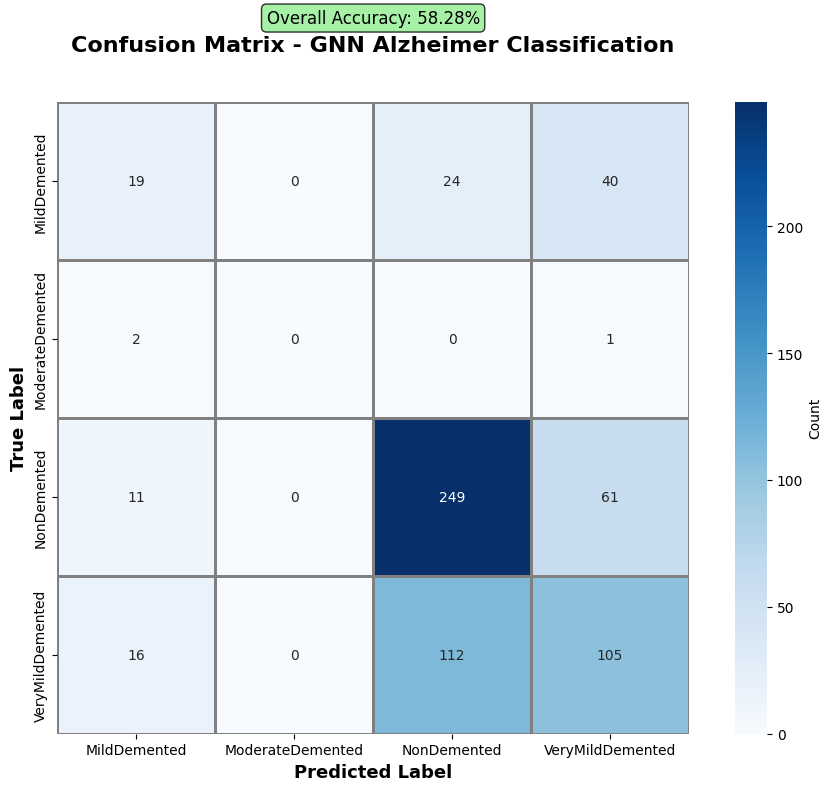


Per-Class Accuracy:
   MildDemented        :  22.89% (19/83)
   ModerateDemented    :   0.00% (0/3)
   NonDemented         :  77.57% (249/321)
   VeryMildDemented    :  45.06% (105/233)


In [16]:
print("Generating confusion matrix...\n")

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=CONFIG['CLASS_NAMES'],
    yticklabels=CONFIG['CLASS_NAMES'],
    cbar_kws={'label': 'Count'},
    square=True,
    linewidths=1,
    linecolor='gray'
)

plt.title('Confusion Matrix - GNN Alzheimer Classification\n', 
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=13, fontweight='bold')

plt.text(
    2, -0.5, 
    f'Overall Accuracy: {test_accuracy:.2f}%',
    fontsize=12,
    ha='center',
    bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8)
)

plt.tight_layout()

cm_path = os.path.join(CONFIG['OUTPUT_DIR'], 'confusion_matrix.png')
plt.savefig(cm_path, dpi=300, bbox_inches='tight')
print(f"Confusion matrix saved to: {cm_path}")
plt.show()

print("\nPer-Class Accuracy:")
for i, class_name in enumerate(CONFIG['CLASS_NAMES']):
    class_correct = cm[i, i]
    class_total = cm[i, :].sum()
    class_acc = 100. * class_correct / class_total if class_total > 0 else 0
    print(f"   {class_name:20s}: {class_acc:6.2f}% ({class_correct}/{class_total})")

# ## Section 15: ROC Curves

Generating ROC curves...

ROC curves saved to: C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\outputs\Q3\Q3a\roc_curves.png


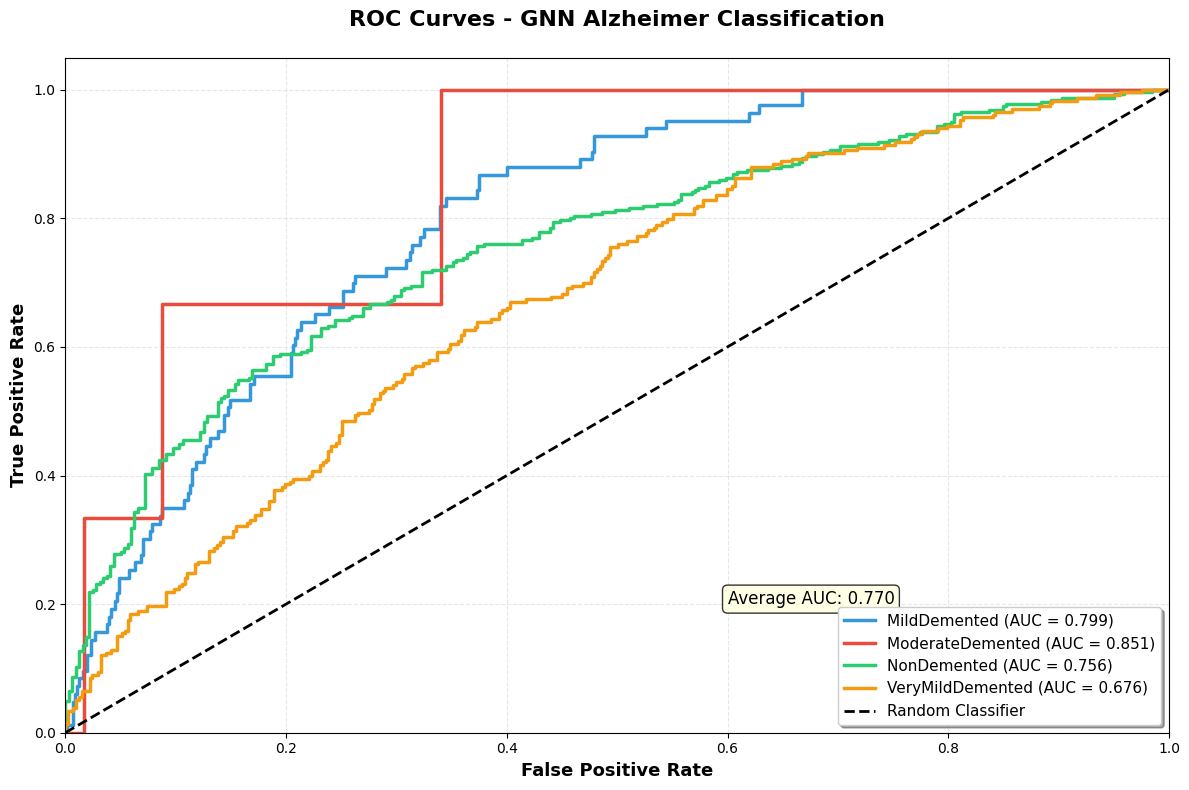


AUC Scores per Class:
   MildDemented        : 0.7988
   ModerateDemented    : 0.8514
   NonDemented         : 0.7557
   VeryMildDemented    : 0.6756

   Average             : 0.7704


In [17]:
print("Generating ROC curves...\n")

y_test_bin = label_binarize(all_labels, classes=range(CONFIG['NUM_CLASSES']))

plt.figure(figsize=(12, 8))

colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
auc_scores = []

for i, (class_name, color) in enumerate(zip(CONFIG['CLASS_NAMES'], colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    auc_scores.append(roc_auc)
    
    plt.plot(fpr, tpr, color=color, lw=2.5,
             label=f'{class_name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=13, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=13, fontweight='bold')
plt.title('ROC Curves - GNN Alzheimer Classification\n', 
          fontsize=16, fontweight='bold')
plt.legend(loc='lower right', fontsize=11, frameon=True, shadow=True)
plt.grid(alpha=0.3, linestyle='--')

avg_auc = np.mean(auc_scores)
plt.text(0.6, 0.2, f'Average AUC: {avg_auc:.3f}', fontsize=12,
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()

roc_path = os.path.join(CONFIG['OUTPUT_DIR'], 'roc_curves.png')
plt.savefig(roc_path, dpi=300, bbox_inches='tight')
print(f"ROC curves saved to: {roc_path}")
plt.show()

print("\nAUC Scores per Class:")
for class_name, auc_score in zip(CONFIG['CLASS_NAMES'], auc_scores):
    print(f"   {class_name:20s}: {auc_score:.4f}")
print(f"\n   {'Average':20s}: {avg_auc:.4f}")


# ## Section 16: Training History Plots

Generating training history plots...

Training history saved to: C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\outputs\Q3\Q3a\training_history.png


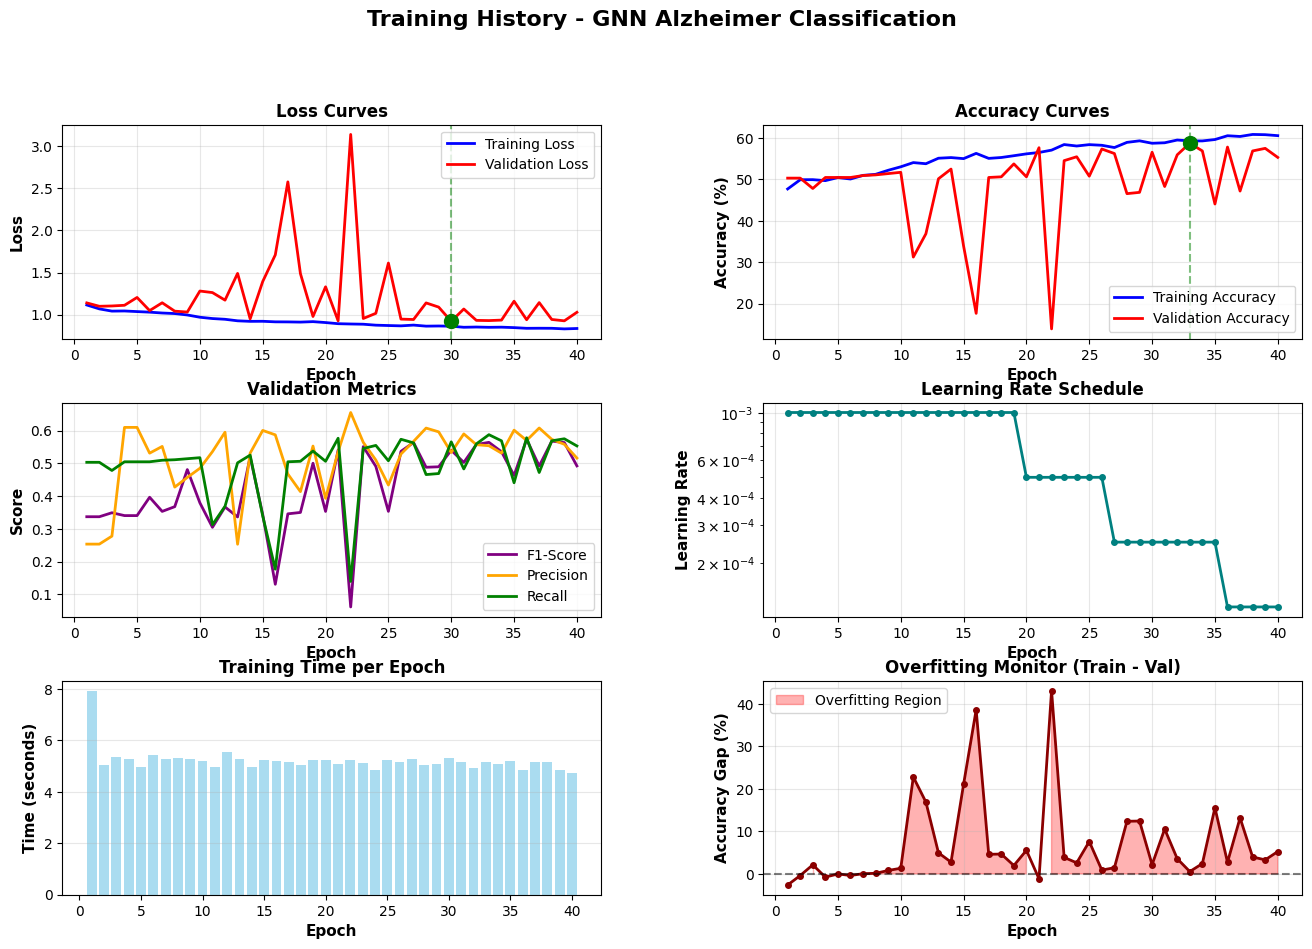


Training Summary:
   Total epochs: 40
   Best validation accuracy: 58.75%
   Best validation loss: 0.9211


In [18]:
print("Generating training history plots...\n")

history = metric_tracker.history

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Loss curves
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(history['epoch'], history['train_loss'], 'b-', linewidth=2, label='Training Loss')
ax1.plot(history['epoch'], history['val_loss'], 'r-', linewidth=2, label='Validation Loss')
ax1.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=11, fontweight='bold')
ax1.set_title('Loss Curves', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(alpha=0.3)

best_epoch_idx = history['val_loss'].index(min(history['val_loss']))
ax1.axvline(x=history['epoch'][best_epoch_idx], color='g', linestyle='--', alpha=0.5)
ax1.plot(history['epoch'][best_epoch_idx], history['val_loss'][best_epoch_idx], 
         'go', markersize=10)

# Accuracy curves
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(history['epoch'], history['train_acc'], 'b-', linewidth=2, label='Training Accuracy')
ax2.plot(history['epoch'], history['val_acc'], 'r-', linewidth=2, label='Validation Accuracy')
ax2.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax2.set_ylabel('Accuracy (%)', fontsize=11, fontweight='bold')
ax2.set_title('Accuracy Curves', fontsize=12, fontweight='bold')
ax2.legend(loc='lower right')
ax2.grid(alpha=0.3)

best_acc_idx = history['val_acc'].index(max(history['val_acc']))
ax2.axvline(x=history['epoch'][best_acc_idx], color='g', linestyle='--', alpha=0.5)
ax2.plot(history['epoch'][best_acc_idx], history['val_acc'][best_acc_idx], 
         'go', markersize=10)

# F1, Precision, Recall
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(history['epoch'], history['val_f1'], 'purple', linewidth=2, label='F1-Score')
ax3.plot(history['epoch'], history['val_precision'], 'orange', linewidth=2, label='Precision')
ax3.plot(history['epoch'], history['val_recall'], 'green', linewidth=2, label='Recall')
ax3.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax3.set_ylabel('Score', fontsize=11, fontweight='bold')
ax3.set_title('Validation Metrics', fontsize=12, fontweight='bold')
ax3.legend(loc='lower right')
ax3.grid(alpha=0.3)

# Learning rate
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(history['epoch'], history['learning_rate'], 'teal', linewidth=2, marker='o', markersize=4)
ax4.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax4.set_ylabel('Learning Rate', fontsize=11, fontweight='bold')
ax4.set_title('Learning Rate Schedule', fontsize=12, fontweight='bold')
ax4.set_yscale('log')
ax4.grid(alpha=0.3)

# Epoch time
ax5 = fig.add_subplot(gs[2, 0])
ax5.bar(history['epoch'], history['epoch_time'], color='skyblue', alpha=0.7)
ax5.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax5.set_ylabel('Time (seconds)', fontsize=11, fontweight='bold')
ax5.set_title('Training Time per Epoch', fontsize=12, fontweight='bold')
ax5.grid(alpha=0.3, axis='y')

# Overfitting monitor
ax6 = fig.add_subplot(gs[2, 1])
gap = [train - val for train, val in zip(history['train_acc'], history['val_acc'])]
ax6.plot(history['epoch'], gap, 'darkred', linewidth=2, marker='o', markersize=4)
ax6.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax6.fill_between(history['epoch'], 0, gap, where=[g > 0 for g in gap], 
                 color='red', alpha=0.3, label='Overfitting Region')
ax6.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax6.set_ylabel('Accuracy Gap (%)', fontsize=11, fontweight='bold')
ax6.set_title('Overfitting Monitor (Train - Val)', fontsize=12, fontweight='bold')
ax6.legend(loc='upper left')
ax6.grid(alpha=0.3)

fig.suptitle('Training History - GNN Alzheimer Classification', 
             fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout()

history_path = os.path.join(CONFIG['OUTPUT_DIR'], 'training_history.png')
plt.savefig(history_path, dpi=300, bbox_inches='tight')
print(f"Training history saved to: {history_path}")
plt.show()

print("\nTraining Summary:")
print(f"   Total epochs: {len(history['epoch'])}")
print(f"   Best validation accuracy: {max(history['val_acc']):.2f}%")
print(f"   Best validation loss: {min(history['val_loss']):.4f}")
